## 7.14 시간 의존 VQE(TD-VQE)를 이용한 들뜬 상태 계산

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_histogram
from qiskit.visualization.state_visualization import plot_state_paulivec
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, partial_trace
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from scipy.linalg import expm
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [3]:
# 정적·시간 의존 해밀토니안 정의
H_static = np.array([[1, 0], [0, -1]])  # 파울리-Z 해밀토니안
H_time_dependent = np.array([[0, 1], [1, 0]])  # 파울리-X 해밀토니안

In [4]:
# 전체 시간 진화 매개변수
time_steps = 100
total_time = 10  # 총 진화 시간
delta_t = total_time / time_steps  # 시간 간격

In [5]:
# 해밀토니안으로 상태를 진화시키는 함수
def time_evolve(state, H, t):
    U = expm(-1j * H * t)  # 시간 진화 연산자 계산
    return U @ state.reshape(H.shape[0], -1)  # 해밀토니안에 맞게 상태 재배열

In [6]:
# 초기 양자 상태
num_qubits = 2
ansatz = EfficientSU2(num_qubits)

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_203/932122584.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits)


In [7]:
# 추정기로 VQE 초기화
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기
vqe = VQE(estimator, ansatz, optimizer=COBYLA())

In [8]:
# 파라미터 수를 앤사츠 파라미터 수와 일치시킴
num_parameters = ansatz.num_parameters
parameters = np.random.rand(num_parameters)  # 올바른 크기의 예시 파라미터
vqe_circuit = ansatz.assign_parameters(parameters)

In [9]:
# 회로에서 상태벡터 초기화
initial_statevector = Statevector.from_instruction(vqe_circuit)

In [10]:
# 여러 시간 단계에 걸쳐 상태벡터를 시간 진화
state = initial_statevector.data
for step in range(time_steps):
    t = step * delta_t
    # 정적·시간 의존 해밀토니안을 교대 적용
    if step % 2 == 0:
        state = time_evolve(state, H_static, delta_t)
    else:
        state = time_evolve(state, H_time_dependent, delta_t)
    state = state.flatten()  # 상태를 열 벡터로 유지

In [11]:
# 시각화를 위해 최종 상태벡터를 Statevector 객체로 변환
final_statevector = Statevector(state.flatten())  # 열 벡터 보장

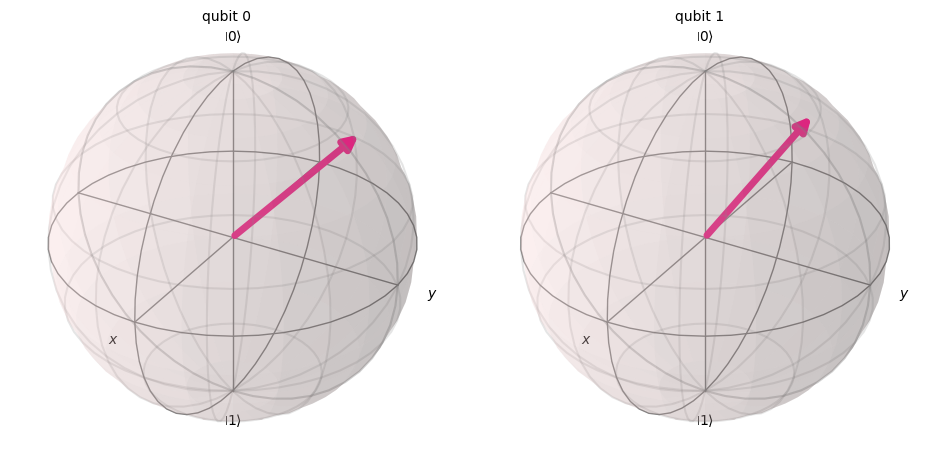

In [12]:
# 블로흐 다중벡터 그리기
plot_bloch_multivector(final_statevector)
plt.show()

<Figure size 640x480 with 0 Axes>

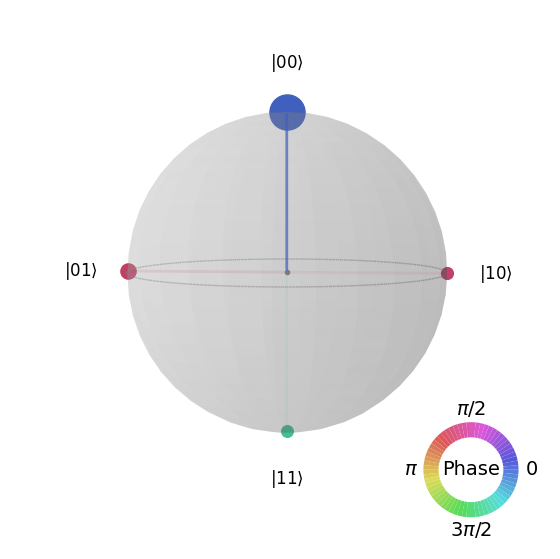

In [13]:
# QSphere 그리기
plt.figure()
plot_state_qsphere(final_statevector)
plt.show()

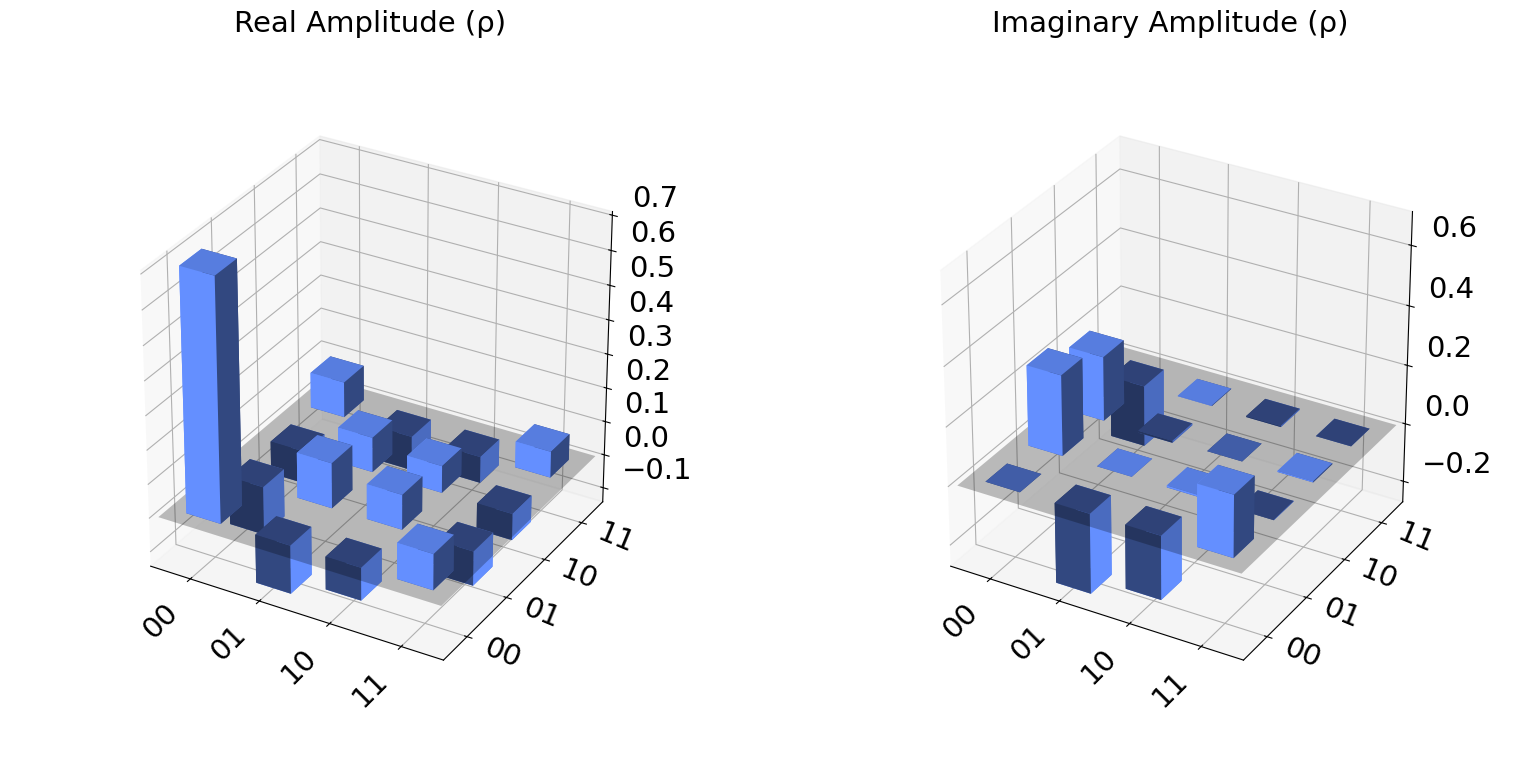

In [14]:
# State City 그리기
plot_state_city(final_statevector)
plt.show()

In [15]:
# 부분 대각합 계산 및 그리기 (큐비트 1 추적 제거)
partial_trace_state = partial_trace(final_statevector, [1])
print("부분 대각합:\n", partial_trace_state)

부분 대각합:
 DensityMatrix([[ 0.78982775-2.48569732e-18j, -0.22119833-2.68585876e-01j],
               [-0.22119833+2.68585876e-01j,  0.21017225+2.78477796e-18j]],
              dims=(2,))


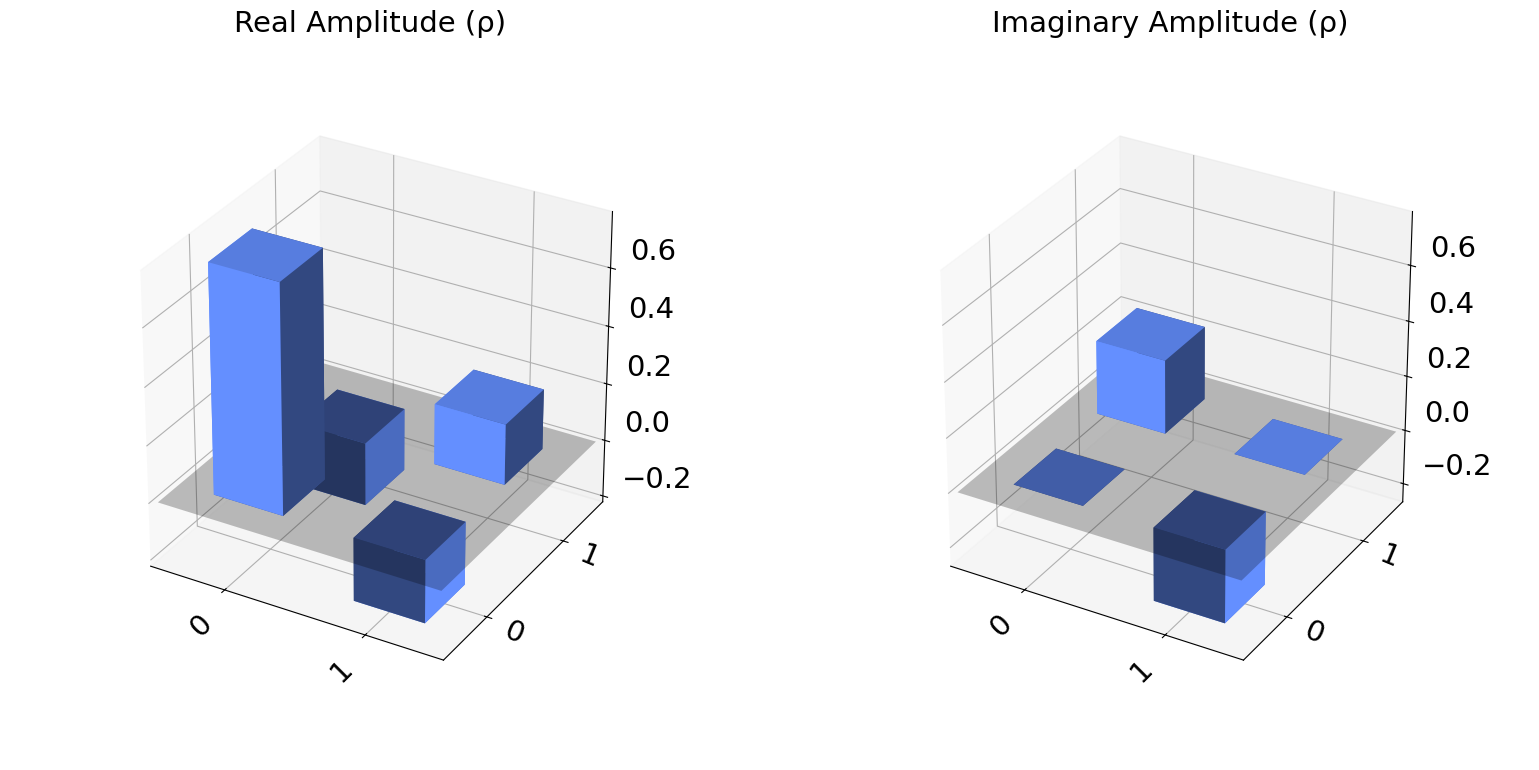

In [16]:
# 고급 상태 검사를 위한 부분 대각합
plot_state_city(partial_trace_state)
plt.show()

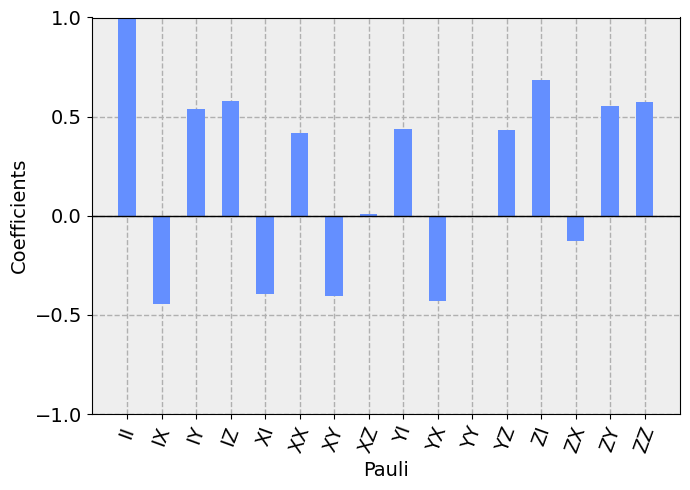

In [17]:
# 파울리 벡터 그리기
plot_state_paulivec(final_statevector)
plt.show()

In [18]:
# 측정 회로 생성
measurement_circuit = QuantumCircuit(num_qubits)
# 최종 상태벡터로 회로 초기화
measurement_circuit.initialize(final_statevector.data, range(num_qubits))
# 모든 큐비트에 측정 추가
measurement_circuit.measure_all()

In [19]:
# 회로 실행
result = simulator.run(measurement_circuit).result()
counts = result.get_counts()

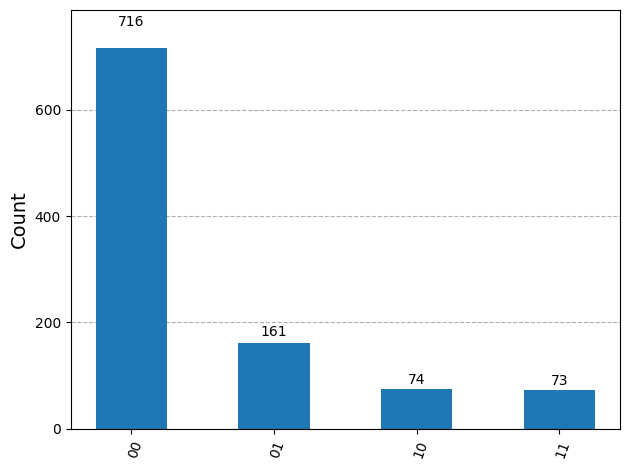

In [20]:
# 히스토그램 그리기
plot_histogram(counts)
plt.show()